In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_notebook_dir() -> Path:
    """Locate the notebooks/ folder regardless of the kernel's working directory."""
    # VS Code exposes the notebook path directly.
    vsc_path = globals().get("__vsc_ipynb_file__")
    if vsc_path:
        return Path(vsc_path).resolve().parent
    # Otherwise walk up from cwd looking for this notebook.
    for d in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (d, d / "notebooks"):
            if (candidate / "explore_dataset.ipynb").exists():
                return candidate.resolve()
    raise FileNotFoundError("Cannot locate notebooks/ folder; start the kernel inside the project.")


NOTEBOOK_DIR = find_notebook_dir()
os.chdir(NOTEBOOK_DIR)

In [2]:
data = pd.read_csv("../data/5k_items_curated.csv")
queries = pd.read_csv("../data/queries.csv")

In [3]:
print(f"{len(data)} rows, {len(queries)} queries")
data.dtypes

5000 rows, 100 queries


_id             str
itemId          str
itemMetadata    str
itemProfile     str
merchantId      str
dtype: object

## Parse

Flatten the `itemMetadata` and `itemProfile` JSON strings into one row per item with typed columns.
Keeps name, category, description, price, taxonomy, dietary flags, tags, images, search terms and a few behavioural metrics (orders, reorder rate, ordering shift).

The dataset is confidential, so cells that print catalog rows, item names, taxonomy samples, search terms or the query list have their outputs cleared. Run the notebook locally with the data in `data/` to see them; aggregate statistics are kept.

In [4]:
import numpy as np

SHIFTS = ["breakfast", "lunch", "snack", "dinner", "dawn"]


def parse_items(raw: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for item_id, merchant_id, meta_s, prof_s in raw[["itemId", "merchantId", "itemMetadata", "itemProfile"]].itertuples(index=False):
        meta, prof = json.loads(meta_s), json.loads(prof_s)
        tax, metrics = meta.get("taxonomy") or {}, prof.get("metrics") or {}
        shift = (metrics.get("orderingRate") or {}).get("shift") or {}
        rows.append({
            "item_id": item_id,
            "merchant_id": merchant_id,
            "name": (meta.get("name") or "").strip(),
            "category_name": (meta.get("category_name") or "").strip(),
            "description": (meta.get("description") or "").strip(),
            "price": float(meta["price"]) if meta.get("price") is not None else np.nan,
            "l0": tax.get("l0"),
            "l1": tax.get("l1"),
            "l2": tax.get("l2"),
            "vegan": bool(meta.get("vegan")),
            "lac_free": bool(meta.get("lacFree")),
            "organic": bool(meta.get("organic")),
            "tags": {t["key"]: list(t["value"]) for t in meta.get("tags") or []},
            "images": list(meta.get("images") or []),
            "search_terms": [
                {"term": t["term"], "count": int(t.get("count") or 0), "method": t.get("method") or "unknown"}
                for t in prof.get("search") or []
            ],
            "total_orders": int(metrics.get("total_orders") or 0),
            "reorder_rate": float(metrics.get("reorderRate") or 0.0),
            "conversion_rate": float(metrics.get("conversionRate") or 0.0),
            **{f"shift_{s}": float(shift.get(s) or 0.0) for s in SHIFTS},
        })
    return pd.DataFrame(rows)


items_all = parse_items(data)
items_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          5000 non-null   str    
 1   merchant_id      5000 non-null   str    
 2   name             5000 non-null   str    
 3   category_name    5000 non-null   str    
 4   description      5000 non-null   str    
 5   price            5000 non-null   float64
 6   l0               5000 non-null   str    
 7   l1               5000 non-null   str    
 8   l2               5000 non-null   str    
 9   vegan            5000 non-null   bool   
 10  lac_free         5000 non-null   bool   
 11  organic          5000 non-null   bool   
 12  tags             5000 non-null   object 
 13  images           5000 non-null   object 
 14  search_terms     5000 non-null   object 
 15  total_orders     5000 non-null   int64  
 16  reorder_rate     5000 non-null   float64
 17  conversion_rate  5000 non

## Dedupe

One `itemId` appears in 4 rows. Check the rows are identical (ignoring `_id`), keep one, and assert 4997 items with no missing name or `l0`.

In [5]:
dup_ids = data.loc[data["itemId"].duplicated(keep=False), "itemId"].unique()
assert all(data.loc[data["itemId"] == i].drop(columns="_id").nunique().max() == 1 for i in dup_ids)
items = items_all.drop_duplicates("item_id").reset_index(drop=True)
assert len(items) == 4997 and items[["name", "l0"]].notna().all().all()
print(f"dup ids: {len(dup_ids)}, items: {len(items)}")

dup ids: 1, items: 4997


## Stats

Quick numbers on the catalog and the queries: items per `l0`, dish types inside `ALIMENTOS_PREPARADOS`, text length and price distributions, tag and search-term coverage, merchants, and the full query list.

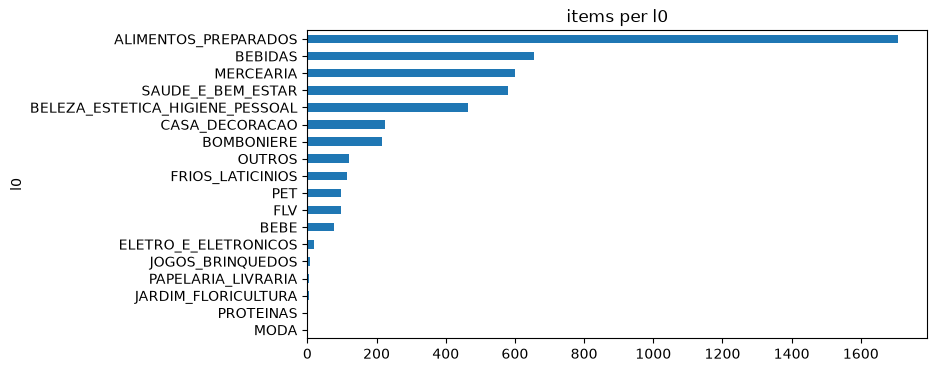

l1
PRATOS                             665
SANDUICHES                         327
SORVETES_ACAIS_FRUTAS              196
SALGADINHOS_APERITIVOS             161
BOLOS_TORTAS_FONDUES               131
PIZZAS                              81
OUTROS                              74
SOBREMESAS                          48
CREPES_PANQUECAS_WRAPS_TAPIOCAS     24
Name: count, dtype: int64

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
items["l0"].value_counts().plot.barh(ax=ax).invert_yaxis()
ax.set_title("items per l0")
plt.show()
items.loc[items["l0"] == "ALIMENTOS_PREPARADOS", "l1"].value_counts()

In [7]:
pd.DataFrame({
    "desc_len": items["description"].str.len().describe(),
    "name_len": items["name"].str.len().describe(),
    "price": items["price"].describe(),
}).round(1)

,desc_len,name_len,price
count,4997.0,4997.0,4997.0
mean,56.7,37.3,29.0
std,107.6,17.5,38.0
min,0.0,2.0,0.0
25%,10.0,24.0,9.1
50%,14.0,36.0,18.7
75%,57.0,48.0,35.0
max,932.0,138.0,1192.1


In [8]:
items.groupby("l0")["price"].describe()[["count", "25%", "50%", "75%"]].sort_values("count", ascending=False)

,count,25%,50%,75%
l0,,,,
ALIMENTOS_PREPARADOS,1707.0,15.4450,28.000,45.8200
BEBIDAS,655.0,6.5000,9.600,16.9900
MERCEARIA,601.0,5.8900,10.840,19.1400
SAUDE_E_BEM_ESTAR,581.0,14.6900,25.990,44.0900
BELEZA_ESTETICA_HIGIENE_PESSOAL,465.0,11.6500,19.990,31.4900
CASA_DECORACAO,225.0,8.0800,14.250,22.2500
BOMBONIERE,217.0,5.5000,10.740,26.9900
OUTROS,120.0,8.9425,16.245,25.7450
FRIOS_LATICINIOS,116.0,9.3900,13.875,18.7425


In [9]:
has_terms = items["search_terms"].str.len() > 0
methods = pd.Series([t["method"] for ts in items["search_terms"] for t in ts]).value_counts()
tag_keys = pd.Series([k for tags in items["tags"] for k in tags]).value_counts()
per_merchant = items["merchant_id"].value_counts()
print(f"items with search terms: {has_terms.sum()}\n{methods}\n\n{tag_keys}")
print(f"\nmerchants: {len(per_merchant)}, single-item: {(per_merchant == 1).sum()}, max: {per_merchant.max()}")
print(f"items with no image: {(items['images'].str.len() == 0).sum()}")

items with search terms: 3938
term             14876
suggestion        3752
historic          1572
trend              208
stackedsearch        8
unknown              3
seemoresearch        1
Name: count, dtype: int64

PORTION_SIZE            2928
DISH_CLASSIFICATION      207
DIETARY_RESTRICTIONS     121
PIZZA_SIZE                24
Name: count, dtype: int64

merchants: 1806, single-item: 1191, max: 73
items with no image: 200


In [10]:
print(f"{len(queries)} queries, words: {queries['search_term_pt'].str.split().str.len().describe().round(1).to_dict()}")
queries["search_term_pt"].tolist()

## Description cleaning

Many descriptions are packaging boilerplate ("Embalagem 500g", "Compra por peso") or repeat the name.
Blank those, collapse whitespace and cut long ones at 300 chars. Check: empty count before/after, most common survivors, and what got removed.

In [11]:
import re

PACKAGING = r"embalagem|unidade|lata|caixa|garrafa|pacote|pote|frasco|bisnaga|tubo|refil|saco|sach[eê]|long neck|vidro|fardo|kit|bandeja|maço|bl[ií]ster|cartela"
BOILERPLATE = [
    re.compile(r"^produto para maiores de 18 anos\.?$", re.I),
    re.compile(r"^compra por peso\.?$", re.I),
    re.compile(r"^imagem ilustrativa", re.I),
    re.compile(rf"^(?:(?:{PACKAGING})\s*)?(?:c/|com)?\s*[\d.,]+\s*[a-zà-ú]{{0,12}}\.?$", re.I),
]
MAX_DESC = 300


def clean_description(text: str, name: str) -> str:
    text = re.sub(r"\s+", " ", text or "").strip()
    if any(p.match(text) for p in BOILERPLATE) or text.lower().rstrip(".") in name.lower():
        return ""
    return text if len(text) <= MAX_DESC else text[:MAX_DESC].rsplit(" ", 1)[0] + "..."


items["description_clean"] = [clean_description(d, n) for d, n in zip(items["description"], items["name"])]
print(f"empty before: {(items['description'] == '').sum()}, after: {(items['description_clean'] == '').sum()}")
items["description_clean"].value_counts().head(20)

In [12]:
removed = items.loc[(items["description"] != "") & (items["description_clean"] == ""), "description"]
removed.value_counts().head(20)

description
Produto para maiores de 18 anos    91
Compra por peso                    85
Unidade 1un                        82
Lata 350ml                         54
Embalagem 500g                     48
Caixa 30cpr                        45
Embalagem 200ml                    44
Embalagem 500ml                    40
Embalagem 100g                     37
Embalagem 300g                     34
Garrafa 2l                         32
Pacote 1kg                         30
Embalagem 200g                     29
Embalagem 1un                      29
Caixa 20cpr                        27
Pacote 500g                        25
Caixa 10cpr                        24
Embalagem 250g                     24
Embalagem 100ml                    23
Embalagem 80g                      23
Name: count, dtype: int64

## Humanize taxonomy

Turn taxonomy codes into readable Portuguese for the doc text (`SANDUICHES` -> "sanduiches"). Sample of l1/l2 values to eyeball.

In [13]:
def humanize(code: str | None) -> str:
    return (code or "").replace("_", " ").lower().strip()


for level in ["l1", "l2"]:
    print(level, items[level].dropna().map(humanize).drop_duplicates().sample(15, random_state=0).tolist())

## Price bucket

Label each item barato / médio / caro by its price tercile within its `l0`, so a cheap dish and a cheap shampoo get the same label on their own scale.

In [14]:
PRICE_LABELS = ["barato", "médio", "caro"]


def price_buckets(df: pd.DataFrame) -> pd.Series:
    ranks = df.groupby("l0")["price"].rank(pct=True)
    return pd.cut(ranks, [0, 1 / 3, 2 / 3, 1], labels=PRICE_LABELS, include_lowest=True).astype(str)


items["price_bucket"] = price_buckets(items)
pd.crosstab(items["l0"], items["price_bucket"]).loc[items["l0"].value_counts().index[:6]]

price_bucket,barato,caro,médio
l0,,,
ALIMENTOS_PREPARADOS,572,567,568
BEBIDAS,218,221,216
MERCEARIA,201,201,199
SAUDE_E_BEM_ESTAR,193,194,194
BELEZA_ESTETICA_HIGIENE_PESSOAL,155,155,155
CASA_DECORACAO,74,76,75


## Item doc text

Build the text indexed by BM25 and embeddings: name, category path, cleaned description, dietary attributes and price bucket. Empty parts are skipped.
Check: word-count stats and one sample doc per `l0`.

In [15]:
ATTR_PT = {
    "VEGAN": "vegano", "VEGETARIAN": "vegetariano", "LAC_FREE": "sem lactose", "GLUTEN_FREE": "sem glúten",
    "SUGAR_FREE": "sem açúcar", "ORGANIC": "orgânico", "NATURAL": "natural", "DIET": "diet", "ZERO": "zero",
    "ALCOHOLIC_DRINK": "bebida alcoólica", "FROSTY": "gelado",
}


def item_attributes(row: pd.Series) -> list[str]:
    codes = [c for c, flag in [("VEGAN", row["vegan"]), ("LAC_FREE", row["lac_free"]), ("ORGANIC", row["organic"])] if flag]
    codes += row["tags"].get("DIETARY_RESTRICTIONS", []) + row["tags"].get("DISH_CLASSIFICATION", [])
    return list(dict.fromkeys(ATTR_PT.get(c, humanize(c)) for c in codes))


def build_doc(row: pd.Series) -> str:
    category = " > ".join(dict.fromkeys(p for p in [row["category_name"], humanize(row["l1"]), humanize(row["l2"])] if p))
    attrs = ", ".join(item_attributes(row))
    parts = [
        row["name"],
        f"Categoria: {category}" if category else "",
        row["description_clean"],
        attrs.capitalize() if attrs else "",
        f"Preço: {row['price_bucket']}",
    ]
    return ". ".join(p.rstrip(".") for p in parts if p) + "."


items["doc"] = items.apply(build_doc, axis=1)
print(items["doc"].str.split().str.len().describe().round(1).to_dict())
for doc in items.groupby("l0").sample(1, random_state=1)["doc"].head(10):
    print("-", doc)

## Food flags

`is_food` from a set of food `l0` values, plus the food-looking categories inside `OUTROS`; `is_dish` for prepared food only.
These feed a soft prior later, never a hard filter. Check: crosstab per `l0` and OUTROS samples on both sides.

In [16]:
FOOD_L0 = {"ALIMENTOS_PREPARADOS", "MERCEARIA", "BEBIDAS", "BOMBONIERE", "FRIOS_LATICINIOS", "FLV", "PROTEINAS"}

NON_FOOD_OUTROS = {
    "Farmácia Veterinária", "Gatos", "Higiene e Beleza", "Higiene e Limpeza", "Limpeza", "Mamãe e Bebê",
    "Medicamentos", "Papéis", "Primeiros Socorros", "Roedores", "Saúde e Bem-Estar", "Suplementos",
    "Suplementos e Vitaminas",
}


def is_food(l0: str, category_name: str) -> bool:
    return l0 in FOOD_L0 or (l0 == "OUTROS" and category_name not in NON_FOOD_OUTROS)


items["is_food"] = [is_food(l0, c) for l0, c in zip(items["l0"], items["category_name"])]
items["is_dish"] = items["l0"] == "ALIMENTOS_PREPARADOS"
print(items[["is_food", "is_dish"]].sum().to_dict())
pd.crosstab(items["l0"], items["is_food"])

{'is_food': 3494, 'is_dish': 1707}


is_food,False,True
l0,,
ALIMENTOS_PREPARADOS,0,1707
BEBE,76,0
BEBIDAS,0,655
BELEZA_ESTETICA_HIGIENE_PESSOAL,465,0
BOMBONIERE,0,217
CASA_DECORACAO,225,0
ELETRO_E_ELETRONICOS,18,0
FLV,0,97
FRIOS_LATICINIOS,0,116


In [17]:
outros = items[items["l0"] == "OUTROS"]
for flag in [True, False]:
    print(flag, sorted(outros.loc[outros["is_food"] == flag, "category_name"].unique()))
    print(flag, items.loc[(items["l0"] == "OUTROS") & (items["is_food"] == flag), "name"].sample(8, random_state=0).tolist())

## BM25 normalization

Tokenizer for BM25: lowercase, word split, drop PT stopwords, Snowball-PT stem, then strip accents.
Check: sample queries/names and whether accent and plural variants collapse to the same token.

In [18]:
import unicodedata

import nltk
from nltk.stem import SnowballStemmer
from unidecode import unidecode

nltk.download("stopwords", quiet=True)

STEMMER = SnowballStemmer("portuguese")
STOPWORDS = {unidecode(w) for w in nltk.corpus.stopwords.words("portuguese")}


def tokenize(text: str) -> list[str]:
    words = re.findall(r"\w+", unicodedata.normalize("NFKC", text).lower())
    return [unidecode(STEMMER.stem(w)) for w in words if unidecode(w) not in STOPWORDS and len(w) > 1]


for text in [*queries["search_term_pt"].sample(5, random_state=0), *items["name"].sample(5, random_state=0)]:
    print(f"{text!r} -> {tokenize(text)}")

In [19]:
for a, b in [("Sanduíches", "sanduiche"), ("Pães", "pão"), ("hambúrgueres", "Hambúrguer"), ("Açaí", "acai"), ("pastéis", "pastel"), ("caseira", "caseiro"), ("flor", "flores")]:
    print(f"{a} {tokenize(a)} | {b} {tokenize(b)} | match={tokenize(a) == tokenize(b)}")

Sanduíches ['sanduich'] | sanduiche ['sanduich'] | match=True
Pães ['pa'] | pão ['pa'] | match=True
hambúrgueres ['hamburgu'] | Hambúrguer ['hamburgu'] | match=True
Açaí ['aca'] | acai ['aca'] | match=True
pastéis ['past'] | pastel ['pastel'] | match=False
caseira ['caseir'] | caseiro ['caseir'] | match=True
flor ['flor'] | flores ['flor'] | match=True


## Search-term noise

Inspect only. `itemProfile.search` looks like co-session queries, not the query that found the item. Measure coverage and show noisy examples; using them is a later ablation.

In [20]:
n_terms = items["search_terms"].str.len()
repeated = items["search_terms"].map(lambda ts: sum(t["count"] >= 2 for t in ts))
print(f"terms per item (with any): {n_terms[n_terms > 0].describe().round(1).to_dict()}")
print(f"share of terms with count>=2: {repeated.sum() / n_terms.sum():.2%}")
for _, row in items[n_terms >= 5].sample(5, random_state=2).iterrows():
    top = sorted(row["search_terms"], key=lambda t: -t["count"])[:6]
    print(f"{row['name']!r}: {[(t['term'], t['count']) for t in top]}")

## Save

Write the cleaned table to `artifacts/items.parquet` (nested fields as JSON strings) and assert the round-trip matches.
This is the prototype: `foodsearch index` (`src/foodsearch/data.py`) now builds the same file, checked identical column by column.

In [21]:
ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)
out = items.drop(columns=["tags", "search_terms"]).assign(
    tags=items["tags"].map(json.dumps),
    search_terms=items["search_terms"].map(lambda ts: json.dumps(ts, ensure_ascii=False)),
)
out.to_parquet(ARTIFACTS / "items.parquet", index=False)
back = pd.read_parquet(ARTIFACTS / "items.parquet")
assert back.shape == out.shape and list(back.columns) == list(out.columns)
assert back["doc"].equals(out["doc"])
print(back.shape, list(back.columns))

(4997, 28) ['item_id', 'merchant_id', 'name', 'category_name', 'description', 'price', 'l0', 'l1', 'l2', 'vegan', 'lac_free', 'organic', 'images', 'total_orders', 'reorder_rate', 'conversion_rate', 'shift_breakfast', 'shift_lunch', 'shift_snack', 'shift_dinner', 'shift_dawn', 'description_clean', 'price_bucket', 'doc', 'is_food', 'is_dish', 'tags', 'search_terms']
